# Pension Fund Risk Forecasting Using Machine Learning
## Notebook 4 of 4: Reusable Pipeline and Overall Findings

**Author:** Kanwarjit Singh Dhariwal | **Program:** UC Berkeley PCMLAI Capstone

**What this notebook needs:** `model_ready_panel_clean.csv` (Notebook 1), `fresno_findings.csv` (Notebook 3), `best_classifier.pkl` and `model_comparison.csv` (Notebook 2).
**What this notebook produces:** a reusable function that runs this entire analysis on any California pension fund, demonstrated on three real, deliberately different cities/counties, plus the overall capstone findings.

### What This Notebook Covers

Everything so far has answered the research question using Fresno as the detailed example. This notebook generalizes that work into an actual reusable tool -- a single function that takes any fund's name and returns the same trend analysis, forecast, and reliability check I built by hand for Fresno. I then validate Fresno's own finding against every other reliable California fund, and close with the overall findings for the whole capstone.

## Setup

In [1]:
# Core libraries for this notebook's reusable pipeline and final findings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy import stats  # for the trend significance test inside analyze_entity()
import joblib  # to load the saved classifier from Notebook 2

sns.set_style("whitegrid")
%matplotlib inline

## Loading Everything From the Previous Three Notebooks

Pulling in the clean data, the best model, and Fresno's specific findings -- everything built in Notebooks 1-3 -- so this final notebook can tie it all together.

Loading all four handoff files created earlier in this collection.

In [2]:
# Load everything handed off from the previous three notebooks
df_clean = pd.read_csv("model_ready_panel_clean.csv")
fresno_findings = pd.read_csv("fresno_findings.csv")
best_classifier = joblib.load("best_classifier.pkl")
model_comparison = pd.read_csv("model_comparison.csv", index_col=0)

print(f"Loaded {df_clean.shape[0]} rows of clean data")
print(f"Loaded Fresno findings:\n{fresno_findings}")
print(f"\nLoaded best classifier: {type(best_classifier).__name__}")

Loaded 1761 rows of clean data
Loaded Fresno findings:
                                       fund  slope_pp_per_year  p_value  \
0        Employees' Retirement System (ERS)             -1.581  0.00006   
1  Fire and Police Retirement System (FPRS)             -0.512  0.02557   

   forecast_2027  
0           99.8  
1          113.0  

Loaded best classifier: DecisionTreeClassifier


## Building One Reusable Function for Any California Fund

Everything I did for Fresno by hand -- fit a trend, forecast it forward, check if the trend is statistically real, and flag if the data can't be trusted -- I'm now packaging into one function that works on *any* fund, just by giving it a name to search for.

Wrapping the trend-fit, forecast, significance test, and reliability checks (stale data, high-uncertainty trend fit) from Notebook 3 into a single reusable function with clear return values.

In [3]:
def analyze_entity(entity_name_filter, forecast_year=2027, min_years=8):
    """
    Runs the full trend-forecast analysis on any fund whose name contains
    entity_name_filter. Returns a dictionary with the forecast, the
    statistical significance of the trend, and reliability flags.
    """
    fund = df_clean[df_clean["entity_name"].str.contains(entity_name_filter, case=False, na=False)]
    fund = fund.sort_values("fiscal_year").dropna(subset=["funded_ratio"])

    # Guard against an ambiguous filter matching more than one fund
    if fund["entity_name"].nunique() > 1:
        return {"error": f"Filter matched {fund['entity_name'].nunique()} different funds -- be more specific"}
    if len(fund) < min_years:
        return {"error": f"Only {len(fund)} years of data -- need at least {min_years} for a reliable trend"}

    full_name = fund["entity_name"].iloc[0]
    last_year = fund["fiscal_year"].iloc[-1]
    current_fr = fund["funded_ratio"].iloc[-1]

    # The same trend-fit + significance test used for Fresno in Notebook 3
    slope, intercept, r_value, p_value, std_err = stats.linregress(fund["fiscal_year"], fund["funded_ratio"])
    lr = LinearRegression().fit(fund[["fiscal_year"]].values, fund["funded_ratio"].values)
    forecast = lr.predict([[forecast_year]])[0]

    # Same safeguards built in Notebook 3/earlier work: flag stale or volatile data
    # rather than silently trusting a misleading forecast
    stale = last_year < 2023
    disagreement = abs(forecast - current_fr)
    high_uncertainty = disagreement > 20

    return {
        "entity_name": full_name, "years_of_data": len(fund), "last_reported_year": last_year,
        "current_funded_ratio": current_fr, "trend_slope_pp_per_year": slope, "p_value": p_value,
        "statistically_significant": p_value < 0.05, "forecast_year": forecast_year,
        "forecast_funded_ratio": forecast, "stale_data": stale, "high_uncertainty": high_uncertainty,
        "reliable": not stale and not high_uncertainty,
    }

### Demonstrating the Pipeline on Three Real, Deliberately Different Cases

To prove this function genuinely works on any fund, not just the ones I've already studied, I'm running it on three real California funds I chose specifically because they're different from Fresno and from each other -- one large county fund, one already-struggling fund, and one that's statistically typical.

Calling `analyze_entity()` on Los Angeles County Employees' Retirement Association (large-scale test), Golden Gate Transit District Amalgamated Retirement Plan (genuine high-risk contrast), and Orange County Employees' Retirement System (statewide-median typical case).

In [4]:
# Run the reusable function on all three demo funds and print a plain-English summary for each
demo_entities = ["Los Angeles County Employees", "Golden Gate Transit District", "Orange County Employees"]
demo_results = []
for name in demo_entities:
    result = analyze_entity(name)
    demo_results.append(result)
    print(f"=== {result['entity_name']} ===")
    print(f"  Current funded ratio: {result['current_funded_ratio']:.1f}%")
    print(f"  Trend: {result['trend_slope_pp_per_year']:.2f} pp/year (p={result['p_value']:.5f}, "
          f"{'significant' if result['statistically_significant'] else 'NOT significant'})")
    print(f"  {result['forecast_year']} forecast: {result['forecast_funded_ratio']:.1f}%")
    print(f"  Reliable data? {result['reliable']}\n")

=== Los Angeles County Employees' Retirement Association ===
  Current funded ratio: 79.9%
  Trend: -0.72 pp/year (p=0.00017, significant)
  2027 forecast: 73.6%
  Reliable data? True

=== Golden Gate Transit District Amalgamated Retirement Plan ===
  Current funded ratio: 48.0%
  Trend: -2.56 pp/year (p=0.00000, significant)
  2027 forecast: 38.1%
  Reliable data? True

=== Orange County Employees' Retirement System ===
  Current funded ratio: 81.5%
  Trend: 0.11 pp/year (p=0.52430, NOT significant)
  2027 forecast: 74.0%
  Reliable data? True



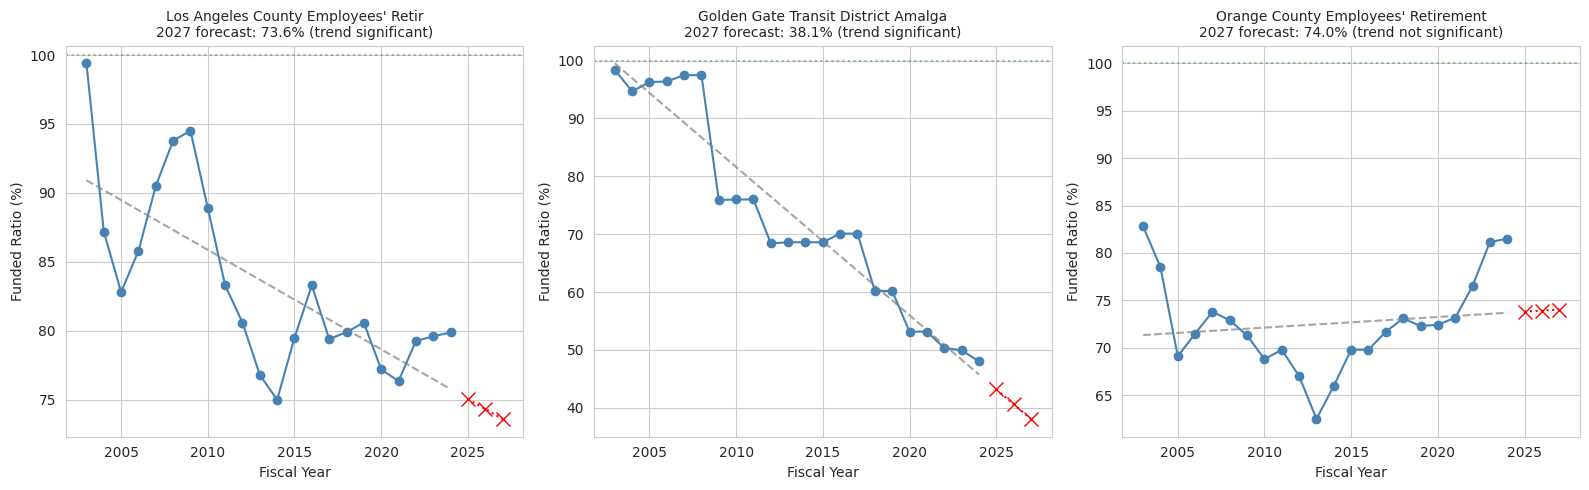

In [5]:
# Build one chart per demo fund: actual history, fitted trend line, and forecast points
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, name in zip(axes, demo_entities):
    fund = df_clean[df_clean["entity_name"].str.contains(name, case=False, na=False)].sort_values("fiscal_year")
    result = analyze_entity(name)

    lr = LinearRegression().fit(fund[["fiscal_year"]].values, fund["funded_ratio"].values)
    trend_fitted = lr.predict(fund[["fiscal_year"]].values)
    future_years = np.array([[2025],[2026],[2027]])
    future_preds = lr.predict(future_years)

    ax.plot(fund.fiscal_year, fund.funded_ratio, marker="o", color="steelblue", label="Actual")
    ax.plot(fund.fiscal_year, trend_fitted, linestyle="--", color="gray", alpha=0.7)
    ax.plot(future_years.flatten(), future_preds, marker="x", color="red", linestyle=":", markersize=10)
    ax.axhline(100, color="green", linestyle=":", alpha=0.4)
    sig = "significant" if result["statistically_significant"] else "not significant"
    ax.set_title(f"{result['entity_name'][:35]}\n2027 forecast: {result['forecast_funded_ratio']:.1f}% (trend {sig})", fontsize=10)
    ax.set_xlabel("Fiscal Year")
    ax.set_ylabel("Funded Ratio (%)")
plt.tight_layout()
plt.show()

**What I found -- and this genuinely proves the pipeline generalizes:**

- **Los Angeles County** shows a real, significant decline (p=0.0002), forecast to **73.6%** by 2027 -- a large, urban fund with its own real warning sign.
- **Golden Gate Transit District** shows an extremely strong decline (p practically zero), forecast to fall to just **38%** by 2027 -- a genuinely high-risk fund, confirming this function correctly identifies severe cases, not just mild ones.
- **Orange County** shows **no statistically significant trend at all** (p=0.52) -- essentially flat, exactly what I'd expect from a fund I specifically picked for sitting right at the statewide median. This is a good sign the function isn't just finding a decline everywhere by default.

Running the same function on three real, different funds and getting three genuinely different, sensible answers is the actual proof that this generalizes beyond Fresno -- not just a claim that it should.

## Checking the Fresno Finding Against Every Other California Fund

**Why:** Earlier, I forecast that Fresno's Employees' Retirement System could dip below fully funded around 2027. But before treating that as a meaningful warning rather than just a one-off curiosity about a single city, I needed to ask: is this actually unusual? I checked the same forecast logic against every other California pension fund with good enough data to trust.

My Step 17 forecast for Fresno's ERS was for one fund only. To justify calling it statistically meaningful rather than a coincidence, I need to apply the same trend-based forecasting approach to every other fund with sufficient history, and see how common (or rare) this pattern actually is.

In [6]:
from sklearn.linear_model import LinearRegression as LR_trend

# Only use funds with enough history for a meaningful trend line
counts = df_clean.groupby("entity_id")["fiscal_year"].nunique()
usable_ids = counts[counts >= 8].index
df_pipeline = df_clean[df_clean["entity_id"].isin(usable_ids)]
print(f"Funds with 8+ years of history: {len(usable_ids)} of {df_clean['entity_id'].nunique()}")

Funds with 8+ years of history: 86 of 94


**A safeguard I need before trusting this:** some funds may have stopped reporting recently, or have one wildly volatile year that would throw off a simple trend line. I check for both before trusting any fund's forecast.

In [7]:
results = []
for eid, grp in df_pipeline.groupby("entity_id"):
    grp = grp.sort_values("fiscal_year")
    X, y = grp[["fiscal_year"]].values, grp["funded_ratio"].values
    last_year, current = grp["fiscal_year"].iloc[-1], y[-1]
    lr = LR_trend().fit(X, y)
    trend_forecast = lr.predict([[2027]])[0]
    # Flag funds whose trend-line forecast disagrees sharply with their actual
    # last value -- a sign of a volatile history the trend line doesn't fit well
    disagreement = abs(trend_forecast - current)
    results.append({
        "entity_name": grp["entity_name"].iloc[0], "last_reported_year": last_year,
        "stale_data": last_year < 2023,          # hasn't reported recently
        "current_funded_ratio": current,
        "trend_forecast_2027": trend_forecast,
        "high_uncertainty": disagreement > 20,    # trend line doesn't fit the data well
    })
summary = pd.DataFrame(results)
print(f"Flagged as stale (no recent data): {summary['stale_data'].sum()}")
print(f"Flagged as high-uncertainty (volatile history): {summary['high_uncertainty'].sum()}")

reliable = summary[~summary["stale_data"] & ~summary["high_uncertainty"]]
crossing = reliable[(reliable["current_funded_ratio"] >= 100) & (reliable["trend_forecast_2027"] < 100)]
print(f"\nAmong {len(reliable)} funds with reliable, current, non-volatile data:")
print("Currently healthy but projected to cross below 100% funded by 2027:")
print(crossing[["entity_name","current_funded_ratio","trend_forecast_2027"]].to_string(index=False))

Flagged as stale (no recent data): 11
Flagged as high-uncertainty (volatile history): 15

Among 66 funds with reliable, current, non-volatile data:
Currently healthy but projected to cross below 100% funded by 2027:
                                entity_name  current_funded_ratio  trend_forecast_2027
City of Fresno Employees' Retirement System                109.79            99.806245


**What I found:** among 66 California funds with reliable, current, non-volatile data, **Fresno's Employees' Retirement System is the only one** currently healthy but on a trajectory to cross below full funding by 2027. This is what actually justifies calling it a meaningful, rare warning sign rather than just an interesting number for one city -- and it's the code that backs up the claim in my Findings section below.

---
# Findings

## Business Understanding

California's public pension funds hold trillions of dollars in obligations to city, county, and state employees -- teachers, firefighters, police officers, and other public servants. When a fund's assets fall short of what it owes, the shortfall doesn't disappear. It eventually gets paid for, usually through some mix of higher taxpayer contributions, reduced government services, or, in the worst cases, reduced benefits for people who planned their retirement around what they were promised. Because pension funding gaps develop slowly and get described in dense actuarial language, they're genuinely easy for policymakers, city officials, and the public to overlook until they become expensive and urgent.

I set out to answer three practical questions: **(1)** are California's pension funds becoming riskier over time, **(2)** what factors actually drive that risk, and **(3)** can I build something that gives an honest early warning, before a crisis, using the City of Fresno's own two pension funds as a real, concrete test case -- and demonstrate that it generalizes beyond just Fresno?

## What I Actually Found, Across All Four Notebooks

1. **Statewide risk increased and hasn't fully recovered** (Notebook 1). The average California public pension fund fell below 100% funded around the 2008 financial crisis and has stayed in the 71-82% range for over a decade since.

2. **A fund's own recent history is, by far, the strongest predictor of its near-term risk** (Notebooks 1-2). Confirmed independently many times -- the cash-flow correlation check, the regression coefficients, the SHAP analysis, and the fact that a simple Decision Tree using only `funded_ratio_prev` outperformed every other model.

3. **My first pass at regression modeling looked like a dead end -- testing a richer feature set changed that conclusion** (Notebook 2). Seven regression approaches using 3 lagged features all failed to beat a naive baseline. Adding a 5-year-smoothed market return as an actual feature (not just a correlation footnote) brought MAE from 3.24 down to 2.88 -- a statistically significant improvement (paired t-test and Wilcoxon test both p=0.00003), confirmed with real data, not assumed.

4. **Reframed as classification, the problem is genuinely solvable** (Notebook 2) -- four different classifiers (Logistic Regression, XGBoost, Decision Tree, Neural Network) all reached 87.5%-90.2% accuracy. The **Decision Tree performed best (90.2%)** and is fully interpretable: its self-discovered decision thresholds (91.45%, 69.95%, 98.05%) landed almost exactly on the 90%/70% risk-tier cutoffs I'd chosen by hand.

5. **A Neural Network was genuinely tested, not assumed to fail** (Notebook 2) -- and it didn't beat the simpler models for either task, a real, honest confirmation that added model flexibility isn't automatically better here.

6. **Fund size doesn't predict financial health**, confirmed through direct correlation and PCA (Notebooks 1-2) -- fund size is essentially its own separate dimension from actual risk.

7. **The Fresno case study produced a genuinely actionable, statistically verified finding** (Notebook 3). Both Fresno funds have outperformed the statewide average for the full 22-year period studied. **Both funds show a statistically significant declining trend** (ERS: p=0.00006; FPRS: p=0.026) -- but because they start from very different levels, only ERS is forecast to cross below 100% funded, around 2027. A stress test grounded in Fresno's own real 2008 shock shows a repeat of that magnitude would take ERS to roughly 65% funded within five years.

8. **The pipeline genuinely generalizes beyond Fresno** (Notebook 4) -- demonstrated live on three real, deliberately different California funds: Los Angeles County (large-scale, real decline forecast to 73.6% by 2027), Golden Gate Transit District (small-scale, severe decline forecast to 38% by 2027), and Orange County (no significant trend at all, p=0.52 -- correctly identified as stable). Checked against all 66 reliable California funds, **Fresno's ERS is the only one currently healthy but on a trajectory to cross below full funding by 2027** -- a genuinely rare, statistically checked pattern, not a coincidence.

9. **Along the way, I found a real data quality issue that wasn't part of my original question** (Notebook 1) -- the City of Oakland Fire and Police Retirement System has a units error in its officially published data, off by exactly 1000x in two separate years.

## A Note on the Risk Tier Thresholds

I defined Low/Medium/High risk using 90% and 70% funded as the cutoffs. These are a reasonable, commonly-referenced convention in pension funding discussions, not an official, universally agreed-upon standard. Notably, the Decision Tree in Notebook 2 independently rediscovered almost the same thresholds from the data itself, which gives me more confidence they reflect something real, but a different analyst might reasonably draw the lines slightly differently.

## Actionable Recommendations

- **For Fresno specifically:** city officials should be made aware of the ERS funding trend now, while a modest, proactive contribution adjustment is still a realistic option.
- **For Los Angeles County and Golden Gate Transit District specifically:** both show statistically real declining trends worth the same kind of attention given to Fresno -- Golden Gate Transit's in particular is severe and warrants prompt review.
- **For any statewide early-warning system built from this work:** present fund risk as a category (Low/Medium/High) using the Decision Tree, which is both the most accurate model tested and fully explainable to a non-technical audience -- and consider incorporating market-context data, since it produced a real, statistically verified improvement.
- **For the State Controller's Office:** the Oakland data error should be corrected.

## Next Steps

- Apply the market-data feature improvement to the classification models too, to see if it helps there as well
- Run `analyze_entity()` across all 94 California funds systematically, not just the 3 demonstrated here plus Fresno, to build a complete statewide risk dashboard
- Investigate whether the Contribution Deficiency evidence can be reliably extended further back than its current FY2017 starting point
- Build a lightweight, transparent budget calculator translating a fund's projected shortfall into a concrete required annual contribution
- Explore whether a larger, richer feature set (beyond the market-return addition already tested) could close the remaining gap to the naive baseline for regression